In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
tau = 10.0  # ms
taus = 2.0  # ms
dt = 0.1    # ms
L = -70.0   # mV
EI = -80.0  # mV
Vth = -50.0 # mV
Vr = -60.0  # mV

N = 20
I = 25.0    # mV
GI = 2.0    # mV

def simulate_ring(T=200.0, G1=1.0, G2=0.2, seed=0):
    steps = int(T / dt)
    t = np.arange(steps + 1) * dt

    # memory potential and conductances for N neurons over time
    V = np.zeros((N, steps + 1))
    gE = np.zeros((N, steps + 1))
    gI = np.zeros((N, steps + 1))

    # set random initial voltages between L and Vr
    rng = np.random.default_rng(seed)
    V[:, 0] = rng.uniform(L, Vr, size=N)

    # a list of N lists to store spike times for all neurons
    spikes = [[] for _ in range(N)]
    decay = np.exp(-dt / taus)
    all_idx = np.arange(N)

    for n in range(steps):                 

        # decay conductances at time step n
        ge = gE[:, n] * decay
        gi = gI[:, n] * decay

        # exponential Euler update for voltage
        A = L + I + gi * EI
        B = 1.0 + ge + gi
        Vinf = A / B
        Vnew = Vinf + (V[:, n] - Vinf) * np.exp(-B * dt / tau)

        # store decayed values for next time step
        gE[:, n+1] = ge
        gI[:, n+1] = gi
        V[:, n+1] = Vnew

        fired = np.where(Vnew >= Vth)[0]

        if len(fired) > 0:
            for i in fired:
                spikes[i].append(t[n+1])

            V[fired, n+1] = Vr

            for i in fired:
                # self-excitation
                gE[i, n+1] += G1

                # nearest-neighbor excitation
                gE[(i-1) % N, n+1] += G2
                gE[(i+1) % N, n+1] += G2

                # global inhibition to all others
                others = all_idx[all_idx != i]
                gI[others, n+1] += GI

    return t, V, spikes

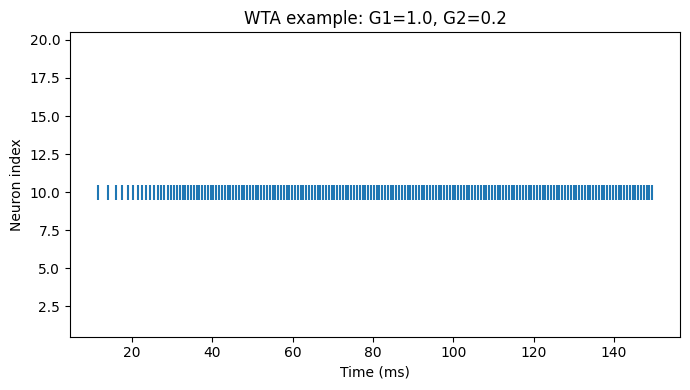

In [2]:
# ---- plot ----

t, V, spikes = simulate_ring(T=150.0, G1=1.0, G2=0.2, seed=0)

plt.figure(figsize=(7,4))
for i in range(N):
    plt.vlines(spikes[i], i + 0.5, i + 1.5)
plt.xlabel("Time (ms)")
plt.ylabel("Neuron index")
plt.title("WTA example: G1=1.0, G2=0.2")
plt.ylim(0.5, N + 0.5)
plt.tight_layout()
plt.show()

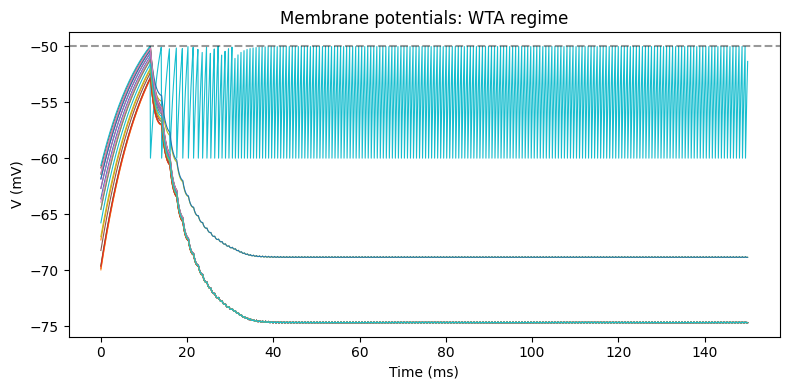

In [3]:
# ---- plot membrane potentials ----

plt.figure(figsize=(8,4))
for i in range(N):
    plt.plot(t, V[i], lw=0.8)
plt.axhline(Vth, ls='--', c='k', alpha=0.4)
plt.xlabel("Time (ms)")
plt.ylabel("V (mV)")
plt.title("Membrane potentials: WTA regime")
plt.tight_layout()
plt.show()